# Workshop 2 · Regresión del precio de vuelos

**Fundamentos de Aprendizaje Automático · 2026-2**

**Integrantes:** Cristian Cabezas, Mateo Lopera y Juanes Villada.

## Objetivo y recorrido

Estimar `price` a partir de características disponibles al consultar un vuelo. Se comparan regresión lineal múltiple, KNN, árbol de decisión, Random Forest y Gradient Boosting, más una referencia trivial. La selección usa **MAE de validación**; test permanece reservado hasta congelar esa decisión. El cierre presenta resultados calculados, validación cruzada y argumentos para sustentación.

Se usan las **300.153 observaciones originales** de `Clean_Dataset.csv`; ninguna muestra sustituye al entrenamiento o a las métricas. Una muestra señalada se permite únicamente para hacer legibles las dispersiones. El precio se expresa en **unidades monetarias del dataset (u.m.)**, sin asumir moneda. El experimento evalúa una partición aleatoria de observaciones del mismo origen; no demuestra rendimiento en fechas futuras ni causalidad.

**Uso:** ejecutar todas las celdas en orden desde un kernel limpio. En local, instalar `requirements.txt` y abrir este archivo desde la carpeta del taller o desde la raíz del repositorio. En Colab, subir únicamente este notebook y ejecutar: la instalación y descarga están incluidas. El CSV puede colocarse manualmente en `data/` si Kaggle no está disponible. El procesamiento completo y la validación cruzada pueden tardar varios minutos y requieren varios GB de RAM.

**Fuentes:** [enunciado del taller](enunciado/Workshop2_ML.pdf), [Kaggle: Flight Price Prediction, versión 2](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction/versions/2), [prevención de fuga de datos en scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html). La disponibilidad de fechas y el diseño de muestreo se limitan a la documentación del dataset; no se infieren identificadores de pasajeros.

## Resultado observado en la ejecución guardada

**Random Forest** obtuvo el menor MAE de validación: **1,093.58 u.m.**; en test alcanzó **1,097.86 u.m.** y **R² = 0.9849**. La media de MAE de CV fue **1,126.25 ± 11.03 u.m.** (cinco folds sobre train). El ranking se mantuvo en test. Se conservaron las 300.153 filas; todos los modelos y métricas usan los conjuntos completos. Estos resultados describen observaciones aleatorias del mismo dataset, con posibles configuraciones de vuelo compartidas entre conjuntos. Las celdas siguientes reconstruyen el experimento y sus salidas; esta síntesis documenta la ejecución entregada.

## 1. Entorno y reproducibilidad

La semilla fija las particiones y los modelos aleatorios. Las dependencias se fijan para reproducir las cifras. En local, instalar previamente `requirements.txt`.

En Colab, ejecutar la primera celda antes de importar bibliotecas. Instala únicamente las versiones pendientes. **Si muestra «REINICIO NECESARIO», seleccionar Entorno de ejecución → Reiniciar sesión y después Ejecutar todo.** Esta detención es intencional: la instalación cambia los archivos en disco, pero los módulos precargados pueden conservar otra versión en memoria. Repetir la celda sin reiniciar no resuelve esa diferencia.

La tabla siguiente comprueba las versiones esperadas, instaladas e importadas. Una vez que coinciden, el notebook puede ejecutarse completo.

In [1]:
import os
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError

DEPENDENCIAS = {
    "numpy": "2.2.6", "pandas": "2.3.3", "scipy": "1.16.3",
    "scikit-learn": "1.7.2", "matplotlib": "3.10.7", "seaborn": "0.13.2",
}
MODULOS_DEPENDENCIAS = {paquete: "sklearn" if paquete == "scikit-learn" else paquete
                       for paquete in DEPENDENCIAS}
EN_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))
pendientes = []
for paquete, esperada in DEPENDENCIAS.items():
    try:
        coincide = version(paquete) == esperada
    except PackageNotFoundError:
        coincide = False
    if not coincide:
        pendientes.append(f"{paquete}=={esperada}")

# pip cambia los archivos en disco, pero no reemplaza módulos ya cargados.
# Esta bandera se elimina solo al reiniciar el kernel, no al repetir la celda.
if EN_COLAB and pendientes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pendientes])
    _WORKSHOP2_REQUIERE_REINICIO = True

modulos_incompatibles = []
for paquete, modulo in MODULOS_DEPENDENCIAS.items():
    if modulo in sys.modules:
        cargada = str(getattr(sys.modules[modulo], "__version__", "desconocida"))
        if cargada != DEPENDENCIAS[paquete]:
            modulos_incompatibles.append(f"{modulo}: {cargada}")

if globals().get("_WORKSHOP2_REQUIERE_REINICIO", False) or modulos_incompatibles:
    detalle = "; ".join(modulos_incompatibles)
    instruccion = (
        "En Colab selecciona Entorno de ejecución > Reiniciar sesión; "
        "después selecciona Ejecutar todo. No basta con repetir esta celda."
        if EN_COLAB else
        "Reinicia el kernel de Jupyter y vuelve a ejecutar todas las celdas."
    )
    raise SystemExit("REINICIO NECESARIO: las bibliotecas en memoria deben coincidir "
                     "con las versiones instaladas. " + instruccion
                     + (" Módulos incompatibles: " + detalle if detalle else ""))
if pendientes and not EN_COLAB:
    raise SystemExit("Instala requirements.txt en este entorno de Python y reinicia "
                     "el kernel antes de ejecutar el notebook. Pendientes: " + ", ".join(pendientes))
print("Python:", sys.version.split()[0], "| Colab:", EN_COLAB,
      "| Dependencias verificadas; se puede continuar.")

Python: 3.12.14 | Colab: False | Dependencias verificadas; se puede continuar.


In [2]:
from importlib import import_module
from pathlib import Path
from io import BytesIO
from urllib.request import Request, urlopen
from zipfile import ZipFile
import hashlib
import json
import platform
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

SEED = 42
np.random.seed(SEED)
# Acotar paralelismo limita picos de memoria sin cambiar el experimento.
limite_hilos = threadpool_limits(limits=4)
set_config(working_memory=512)
BASE = Path.cwd()
if (BASE / "workshop_2").is_dir():
    BASE = BASE / "workshop_2"
DATA_DIR, REPORT_DIR, FIG_DIR = [BASE / nombre for nombre in ("data", "reportes", "figuras")]
for carpeta in (DATA_DIR, REPORT_DIR, FIG_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)

AZUL, NARANJA, GRIS = "#3569A8", "#C87832", "#454545"
sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "grid.alpha": 0.25, "axes.titleweight": "semibold", "axes.labelcolor": GRIS})
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

def guardar_figura(fig, nombre):
    fig.savefig(FIG_DIR / f"regresion_{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

versiones_efectivas = {
    paquete: str(import_module(modulo).__version__)
    for paquete, modulo in MODULOS_DEPENDENCIAS.items()
}
entorno = pd.DataFrame([
    {"paquete": paquete, "version_esperada": esperada,
     "version_instalada": version(paquete), "version_importada": versiones_efectivas[paquete]}
    for paquete, esperada in DEPENDENCIAS.items()
])
display(entorno)
if not (entorno.version_esperada.equals(entorno.version_instalada)
        and entorno.version_esperada.equals(entorno.version_importada)):
    raise RuntimeError("Las versiones en disco y memoria deben coincidir con las fijadas. "
                       "Reinicia la sesión o el kernel y vuelve a ejecutar desde el principio.")
print("Directorio del taller:", BASE)

,paquete,version_esperada,version_instalada,version_importada
0,numpy,2.2.6,2.2.6,2.2.6
1,pandas,2.3.3,2.3.3,2.3.3
2,scipy,1.16.3,1.16.3,1.16.3
3,scikit-learn,1.7.2,1.7.2,1.7.2
4,matplotlib,3.10.7,3.10.7,3.10.7
5,seaborn,0.13.2,0.13.2,0.13.2


Directorio del taller: S:\Github\Workshop_1\workshop_2


## 2. Datos, objetivo y auditoría inicial · puntos 1–6

La descarga utiliza la versión 2 de Kaggle y extrae solo el CSV esperado en memoria. Se verifica su huella SHA-256 antes de analizarlo: una diferencia detiene la ejecución para impedir mezclar versiones silenciosamente. El CSV original se conserva; la limpieza ocurre en una copia.

In [3]:
CSV_PATH = DATA_DIR / "Clean_Dataset.csv"
DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/shubhambathwal/flight-price-prediction?datasetVersionNumber=2"
EXPECTED_SHA256 = "c27377aa4451d4427794523f3292dd2c2dc312f29c6d880aef4df1dcf1aaf7a3"
if not CSV_PATH.exists():
    try:
        peticion = Request(DATASET_URL, headers={"User-Agent": "Workshop2-reproducible/1.0"})
        with urlopen(peticion, timeout=180) as respuesta:
            archivo_zip = respuesta.read()
        with ZipFile(BytesIO(archivo_zip)) as comprimido:
            coincidencias = [n for n in comprimido.namelist() if Path(n).name == CSV_PATH.name]
            if len(coincidencias) != 1:
                raise ValueError("El ZIP no contiene exactamente un Clean_Dataset.csv.")
            contenido_csv = comprimido.read(coincidencias[0])
        if hashlib.sha256(contenido_csv).hexdigest() != EXPECTED_SHA256:
            raise ValueError("La huella de la descarga no coincide con la versión verificada.")
        CSV_PATH.write_bytes(contenido_csv)
    except Exception as error:
        raise RuntimeError(
            f"No fue posible descargar los datos. Descarga la versión 2 de Kaggle, coloca "
            f"Clean_Dataset.csv en {DATA_DIR} y reejecuta. Detalle: {error}"
        ) from error

sha256 = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
assert sha256 == EXPECTED_SHA256, f"Huella inesperada: {sha256}. Revisar versión del CSV."
raw = pd.read_csv(CSV_PATH)
assert raw.shape == (300153, 12), f"Dimensiones inesperadas: {raw.shape}"
fuente = {
    "dataset": "Flight Price Prediction", "publicador": "shubhambathwal", "version_kaggle": 2,
    "pagina": "https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction/versions/2",
    "url_descarga": DATASET_URL, "archivo": CSV_PATH.name, "sha256": sha256,
    "filas_originales": len(raw), "columnas_originales": raw.shape[1],
    "fecha_ejecucion_utc": datetime.now(timezone.utc).isoformat(),
}
display(pd.Series(fuente, name="procedencia").to_frame())
display(raw.head())
display(raw.tail())
print("Dimensiones originales:", raw.shape)
raw.info()
display(raw.dtypes.rename("tipo_original").to_frame())

,procedencia
dataset,Flight Price Prediction
publicador,shubhambathwal
version_kaggle,2
pagina,https://www.kaggle.com/datasets/shubhambathwal...
url_descarga,https://www.kaggle.com/api/v1/datasets/downloa...
archivo,Clean_Dataset.csv
sha256,c27377aa4451d4427794523f3292dd2c2dc312f29c6d88...
filas_originales,300153
columnas_originales,12
fecha_ejecucion_utc,2026-09-07T23:33:44.001473+00:00


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


Dimensiones originales: (300153, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,tipo_original
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


In [4]:
diccionario = pd.DataFrame([
    ("Unnamed: 0", "Índice de exportación", "Identificador", "Excluir: no describe el vuelo"),
    ("airline", "Aerolínea", "Categórica nominal", "Predictor"),
    ("flight", "Código de vuelo", "Identificador categórico", "Excluir: alta cardinalidad"),
    ("source_city", "Ciudad de origen", "Categórica nominal", "Predictor"),
    ("departure_time", "Franja de salida", "Categórica nominal", "Predictor"),
    ("stops", "Categoría del número de escalas", "Categórica ordinal", "One-Hot; sin imponer distancias"),
    ("arrival_time", "Franja de llegada", "Categórica nominal", "Predictor"),
    ("destination_city", "Ciudad de destino", "Categórica nominal", "Predictor"),
    ("class", "Clase de cabina", "Categórica nominal", "Predictor"),
    ("duration", "Duración total del viaje en horas", "Numérica continua", "Predictor"),
    ("days_left", "Días entre reserva y salida", "Numérica discreta", "Predictor"),
    ("price", "Precio del billete en u.m. del dataset", "Numérica", "Variable objetivo"),
], columns=["variable", "significado", "naturaleza", "uso"])
assert set(diccionario.variable) == set(raw.columns)
display(diccionario)

auditoria = pd.DataFrame({
    "tipo": raw.dtypes.astype(str), "nulos": raw.isna().sum(),
    "nulos_pct": 100 * raw.isna().mean(), "valores_distintos": raw.nunique(dropna=False),
})
display(auditoria)
auditoria.to_csv(REPORT_DIR / "regresion_auditoria_original.csv", encoding="utf-8", index_label="variable")

,variable,significado,naturaleza,uso
0,Unnamed: 0,Índice de exportación,Identificador,Excluir: no describe el vuelo
1,airline,Aerolínea,Categórica nominal,Predictor
2,flight,Código de vuelo,Identificador categórico,Excluir: alta cardinalidad
3,source_city,Ciudad de origen,Categórica nominal,Predictor
4,departure_time,Franja de salida,Categórica nominal,Predictor
5,stops,Categoría del número de escalas,Categórica ordinal,One-Hot; sin imponer distancias
6,arrival_time,Franja de llegada,Categórica nominal,Predictor
7,destination_city,Ciudad de destino,Categórica nominal,Predictor
8,class,Clase de cabina,Categórica nominal,Predictor
9,duration,Duración total del viaje en horas,Numérica continua,Predictor


,tipo,nulos,nulos_pct,valores_distintos
Unnamed: 0,int64,0,0.0,300153
airline,object,0,0.0,6
flight,object,0,0.0,1561
source_city,object,0,0.0,6
departure_time,object,0,0.0,6
stops,object,0,0.0,3
arrival_time,object,0,0.0,6
destination_city,object,0,0.0,6
class,object,0,0.0,2
duration,float64,0,0.0,476


### Limpieza determinista y duplicados · puntos 5–6

Se eliminan espacios externos y se normalizan celdas vacías como nulos. Las columnas numéricas se convierten con errores explícitos y se comprueban rangos físicos básicos; no se corrigen observaciones usando la distribución completa. Se retira el índice de exportación y se buscan duplicados completos **incluyendo `flight` y `price`**: códigos de vuelo distintos o precios distintos representan observaciones diferentes y se conservan. Luego se excluye `flight` del modelado por su papel identificador y alta cardinalidad; esta decisión también reduce el riesgo de memorizar códigos. La eventual igualdad de predictores tras esa exclusión se reporta, sin borrar esos registros.

Los valores faltantes en predictores se conservarían hasta el imputador dentro del pipeline; un target nulo no serviría para aprendizaje supervisado y se excluiría con conteo explícito. No se fuerza una eliminación si la auditoría no detecta problemas.

In [5]:
datos = raw.copy()
filas_iniciales = len(datos)
auditoria_formato = []
for columna in datos.select_dtypes(include="object").columns:
    original = datos[columna].copy()
    datos[columna] = datos[columna].str.strip().replace("", np.nan)
    etiquetas = datos[columna].dropna().unique()
    normalizadas = {etiqueta.casefold() for etiqueta in etiquetas}
    auditoria_formato.append({"variable": columna,
        "espacios_corregidos": int((original.fillna("") != datos[columna].fillna("")).sum()),
        "etiquetas": ", ".join(sorted(etiquetas)) if columna != "flight" else "Códigos; ver cardinalidad",
        "colisiones_mayusculas": len(etiquetas) - len(normalizadas)})
auditoria_formato = pd.DataFrame(auditoria_formato)
display(auditoria_formato)
assert auditoria_formato.colisiones_mayusculas.eq(0).all(), "Revisar etiquetas que solo difieren en mayúsculas."
for columna in ("duration", "days_left", "price"):
    datos[columna] = pd.to_numeric(datos[columna], errors="raise")
assert datos.duration.dropna().gt(0).all()
assert datos.days_left.dropna().ge(0).all()
assert datos.price.dropna().gt(0).all()

datos = datos.drop(columns=["Unnamed: 0"])
duplicados_completos = int(datos.duplicated().sum())
datos = datos.drop_duplicates().copy()
targets_nulos = int(datos.price.isna().sum())
datos = datos.dropna(subset=["price"])
codigos_distintos = int(datos.flight.nunique())
datos = datos.drop(columns="flight")
perfiles_precio_iguales = int(datos.duplicated().sum())
predictores_iguales = int(datos.drop(columns="price").duplicated().sum())
datos = datos.reset_index(drop=True)
limpieza = pd.DataFrame([
    {"paso": "CSV original", "filas": filas_iniciales, "columnas": raw.shape[1]},
    {"paso": "Retirar índice y duplicados completos", "filas": filas_iniciales - duplicados_completos, "columnas": 11},
    {"paso": "Retirar target nulo y flight", "filas": len(datos), "columnas": datos.shape[1]},
])
display(limpieza)
display(pd.DataFrame({"nulos_despues": datos.isna().sum(), "porcentaje": 100 * datos.isna().mean()}))
display(Markdown(
    f"**Resultado:** {duplicados_completos:,} duplicados completos y {targets_nulos:,} objetivos nulos "
    f"eliminados; quedan **{len(datos):,} registros**. `flight` contenía **{codigos_distintos:,} códigos**. "
    f"Al retirar ese código, **{perfiles_precio_iguales:,} filas adicionales** coinciden en predictores y precio, "
    "pero no eran duplicados completos de las observaciones originales y se mantienen. "
    f"Hay **{predictores_iguales:,} filas adicionales con predictores iguales** tras excluir identificadores; "
    "se conservan porque la misma configuración puede tener precios diferentes. La partición aleatoria "
    "puede compartir configuraciones entre conjuntos, por lo que la evaluación representa nuevas observaciones "
    "del mismo dominio y no rutas o códigos de vuelo completamente inéditos."
))
limpieza.to_csv(REPORT_DIR / "regresion_limpieza.csv", index=False)

,variable,espacios_corregidos,etiquetas,colisiones_mayusculas
0,airline,0,"AirAsia, Air_India, GO_FIRST, Indigo, SpiceJet...",0
1,flight,0,Códigos; ver cardinalidad,0
2,source_city,0,"Bangalore, Chennai, Delhi, Hyderabad, Kolkata,...",0
3,departure_time,0,"Afternoon, Early_Morning, Evening, Late_Night,...",0
4,stops,0,"one, two_or_more, zero",0
5,arrival_time,0,"Afternoon, Early_Morning, Evening, Late_Night,...",0
6,destination_city,0,"Bangalore, Chennai, Delhi, Hyderabad, Kolkata,...",0
7,class,0,"Business, Economy",0


,paso,filas,columnas
0,CSV original,300153,12
1,Retirar índice y duplicados completos,300153,11
2,Retirar target nulo y flight,300153,10


,nulos_despues,porcentaje
airline,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0
days_left,0,0.0
price,0,0.0


**Resultado:** 0 duplicados completos y 0 objetivos nulos eliminados; quedan **300,153 registros**. `flight` contenía **1,561 códigos**. Al retirar ese código, **2,213 filas adicionales** coinciden en predictores y precio, pero no eran duplicados completos de las observaciones originales y se mantienen. Hay **7,108 filas adicionales con predictores iguales** tras excluir identificadores; se conservan porque la misma configuración puede tener precios diferentes. La partición aleatoria puede compartir configuraciones entre conjuntos, por lo que la evaluación representa nuevas observaciones del mismo dominio y no rutas o códigos de vuelo completamente inéditos.

## 3. Particiones antes del EDA · punto 11

Se reservan aproximadamente **70 % train, 15 % validación y 15 % test**, con `random_state=42`. Primero se separa test y luego se obtiene validación con `0.15 / 0.85` de las filas restantes. El pequeño redondeo entero se muestra abajo. **Train** aprende los parámetros; **validación** permite comparar modelos y escoger uno; **test** estima su desempeño final después de cerrar esa decisión. Solo train/test no basta si se quiere comparar alternativas: elegir repetidamente mirando test acabaría adaptando la elección a él. Todos los modelos reciben exactamente estas mismas filas. El EDA posterior y las decisiones sobre escalamiento/outliers usan solo train. Test se mantiene fuera de esas inspecciones y no participa en la elección del ganador.

In [6]:
TARGET = "price"
NUMERICAS = ["duration", "days_left"]
CATEGORICAS = [c for c in datos.columns if c not in NUMERICAS + [TARGET]]
X, y = datos.drop(columns=TARGET), datos[TARGET]
X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo, y_desarrollo, test_size=0.15 / 0.85, random_state=SEED
)
indices = {"train": set(X_train.index), "validacion": set(X_val.index), "test": set(X_test.index)}
assert not indices["train"] & indices["validacion"]
assert not indices["train"] & indices["test"]
assert not indices["validacion"] & indices["test"]
assert set.union(*indices.values()) == set(datos.index)
assert TARGET not in X.columns and "flight" not in X.columns and "Unnamed: 0" not in X.columns
particiones = pd.DataFrame([
    {"conjunto": nombre, "filas": len(idx), "porcentaje": 100 * len(idx) / len(datos)}
    for nombre, idx in indices.items()
])
display(particiones)
particiones.to_csv(REPORT_DIR / "regresion_particiones.csv", index=False)
pd.Series({i: nombre for nombre, idx in indices.items() for i in idx}, name="conjunto").sort_index().to_csv(
    REPORT_DIR / "regresion_indices_particiones.csv", index_label="fila_limpia"
)
eda = X_train.assign(price=y_train)

,conjunto,filas,porcentaje
0,train,210107,70.0
1,validacion,45023,15.0
2,test,45023,15.0


## 4. EDA sobre entrenamiento · puntos 3 y 7–8

Las estadísticas, proporciones y figuras de esta sección describen exclusivamente entrenamiento. No son estimaciones causales. Cada gráfico incluye una lectura y una acción razonable; los conteos provienen del conjunto completo, excepto las dispersiones visuales señaladas.

In [7]:
estadisticos = eda[NUMERICAS + [TARGET]].describe().T
estadisticos["mediana"] = eda[NUMERICAS + [TARGET]].median()
estadisticos["asimetria"] = eda[NUMERICAS + [TARGET]].skew()
display(estadisticos)
media_precio, mediana_precio, sd_precio = y_train.mean(), y_train.median(), y_train.std()
display(Markdown(
    f"**Tres estadísticos interpretados.** (1) El precio medio es **{media_precio:,.2f} u.m.**, "
    f"un centro sensible a billetes caros. (2) La mediana es **{mediana_precio:,.2f} u.m.**, "
    f"frente a una media {media_precio / mediana_precio:.2f} veces mayor; esto es consistente con "
    "una distribución que no se resume bien con un único precio típico. (3) La desviación estándar es "
    f"**{sd_precio:,.2f} u.m.**, señal de dispersión relevante para interpretar el error del modelo. "
    f"Además, la duración mediana es **{eda.duration.median():.2f} horas** y el intervalo intercuartílico "
    f"del precio es **{y_train.quantile(.75) - y_train.quantile(.25):,.2f} u.m.**. "
    "Recomendación: reportar MAE junto con MSE y revisar errores por clase de cabina."
))
estadisticos.to_csv(REPORT_DIR / "regresion_estadisticos_train.csv", index_label="variable")

,count,mean,std,min,25%,50%,75%,max,mediana,asimetria
duration,210107.0,12.2225,7.1955,0.83,6.83,11.25,16.17,49.83,11.25,0.6042
days_left,210107.0,26.0003,13.5611,1.00,15.00,26.00,38.00,49.00,26.00,-0.0368
price,210107.0,20902.8147,22702.0793,1105.00,4783.00,7425.00,42521.00,123071.00,7425.00,1.0594


**Tres estadísticos interpretados.** (1) El precio medio es **20,902.81 u.m.**, un centro sensible a billetes caros. (2) La mediana es **7,425.00 u.m.**, frente a una media 2.82 veces mayor; esto es consistente con una distribución que no se resume bien con un único precio típico. (3) La desviación estándar es **22,702.08 u.m.**, señal de dispersión relevante para interpretar el error del modelo. Además, la duración mediana es **11.25 horas** y el intervalo intercuartílico del precio es **37,738.00 u.m.**. Recomendación: reportar MAE junto con MSE y revisar errores por clase de cabina.

### Outliers con IQR · punto 7

Se define `IQR = Q3 − Q1`; un valor es extremo si queda fuera de `[Q1 − 1.5 IQR, Q3 + 1.5 IQR]`. Se aplica a `duration` y `price` sobre train. Una bandera estadística no prueba un error: vuelos largos con escalas y billetes de cabina superior pueden ser legítimos. No se eliminan ni recortan valores; se conserva la población objetivo. `RobustScaler` reduce la influencia de extremos en la escala de los predictores, aunque **no elimina outliers ni hace robusta la función de pérdida**. MAE es menos sensible que MSE a errores extremos.

In [8]:
filas_iqr = []
for columna in ("duration", "price"):
    q1, q3 = eda[columna].quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    bandera = (eda[columna] < inferior) | (eda[columna] > superior)
    filas_iqr.append({"variable": columna, "Q1": q1, "Q3": q3, "IQR": iqr,
                      "limite_inferior": inferior, "limite_superior": superior,
                      "extremos": int(bandera.sum()), "porcentaje": bandera.mean() * 100})
iqr_tabla = pd.DataFrame(filas_iqr)
display(iqr_tabla)
display(Markdown("**Decisión aplicada:** conservar todos los registros; los límites anteriores describen train "
                 "y no se usan para seleccionar observaciones de validación o test."))
iqr_tabla.to_csv(REPORT_DIR / "regresion_iqr_train.csv", index=False)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,extremos,porcentaje
0,duration,6.83,16.17,9.34,-7.18,30.18,1508,0.7177
1,price,4783.00,42521.00,37738.00,-51824.00,99128.00,83,0.0395


**Decisión aplicada:** conservar todos los registros; los límites anteriores describen train y no se usan para seleccionar observaciones de validación o test.

### Barras: composición por aerolínea · punto 8

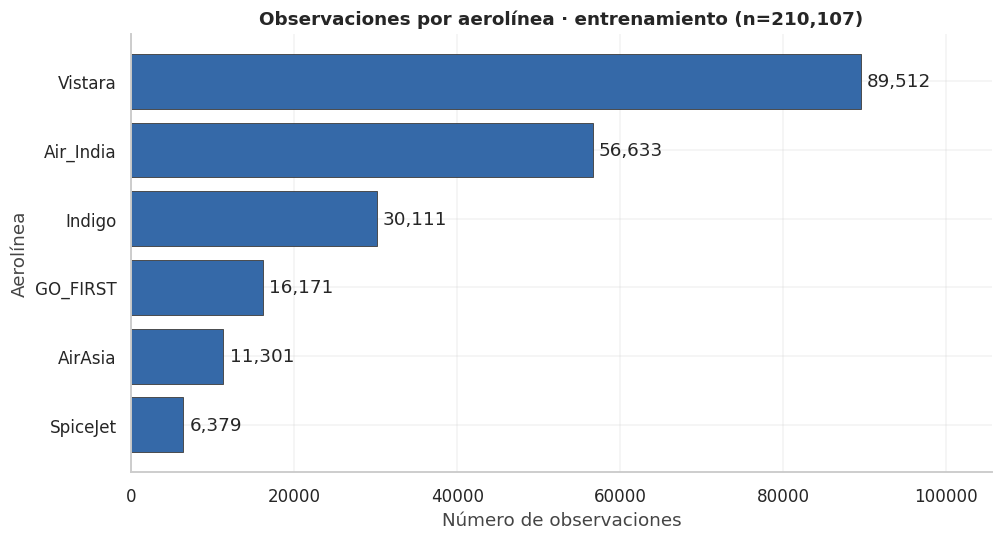

**Lectura:** Vistara aporta **89,512 registros (42.6%)**. El dataset no reparte observaciones por igual entre aerolíneas. **Recomendación:** desagregar el error por aerolínea antes de usar el modelo en decisiones; una buena métrica global puede esconder resultados débiles en grupos pequeños.

In [9]:
conteos_aerolinea = eda.airline.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
ax.barh(conteos_aerolinea.index, conteos_aerolinea.values, color=AZUL, edgecolor=GRIS, linewidth=0.6)
ax.set(title=f"Observaciones por aerolínea · entrenamiento (n={len(eda):,})", xlabel="Número de observaciones", ylabel="Aerolínea")
ax.set_xlim(0, conteos_aerolinea.max() * 1.18)
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in conteos_aerolinea.values], padding=4)
guardar_figura(fig, "eda_barras")
mayor_aerolinea = conteos_aerolinea.idxmax()
display(Markdown(
    f"**Lectura:** {mayor_aerolinea} aporta **{conteos_aerolinea.max():,} registros "
    f"({conteos_aerolinea.max() / len(eda):.1%})**. El dataset no reparte observaciones por igual entre aerolíneas. "
    "**Recomendación:** desagregar el error por aerolínea antes de usar el modelo en decisiones; "
    "una buena métrica global puede esconder resultados débiles en grupos pequeños."
))

### Pie: composición por clase de cabina · punto 8

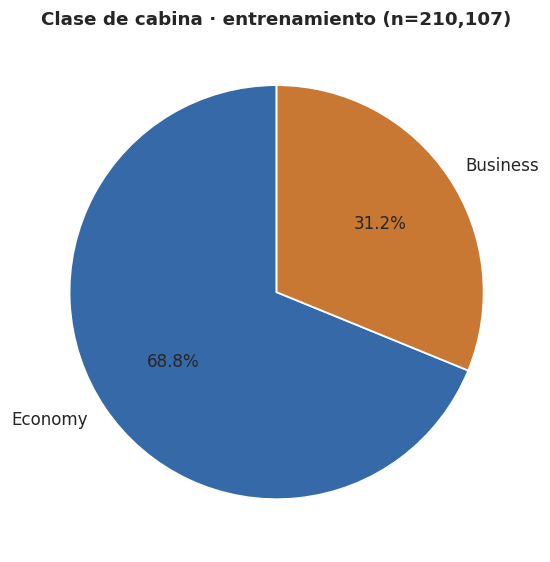

**Lectura:** Economy representa **68.8%** y Business **31.2%** del entrenamiento. Son proporciones de esta muestra, no cuotas del mercado aéreo. **Recomendación:** conservar `class` como predictor y comparar errores por cabina; la composición afecta la métrica agregada.

In [10]:
conteos_clase = eda["class"].value_counts().reindex(["Economy", "Business"])
fig, ax = plt.subplots(figsize=(7.4, 5), layout="constrained")
ax.pie(conteos_clase.values, labels=conteos_clase.index, autopct="%1.1f%%", startangle=90,
       colors=[AZUL, NARANJA], wedgeprops={"edgecolor": "white", "linewidth": 1.2}, textprops={"fontsize": 11})
ax.set_title(f"Clase de cabina · entrenamiento (n={len(eda):,})")
guardar_figura(fig, "eda_pie")
display(Markdown(
    f"**Lectura:** Economy representa **{conteos_clase['Economy'] / len(eda):.1%}** y Business "
    f"**{conteos_clase['Business'] / len(eda):.1%}** del entrenamiento. Son proporciones de esta muestra, "
    "no cuotas del mercado aéreo. **Recomendación:** conservar `class` como predictor y comparar errores "
    "por cabina; la composición afecta la métrica agregada."
))

### Histograma: distribución de precios · punto 8

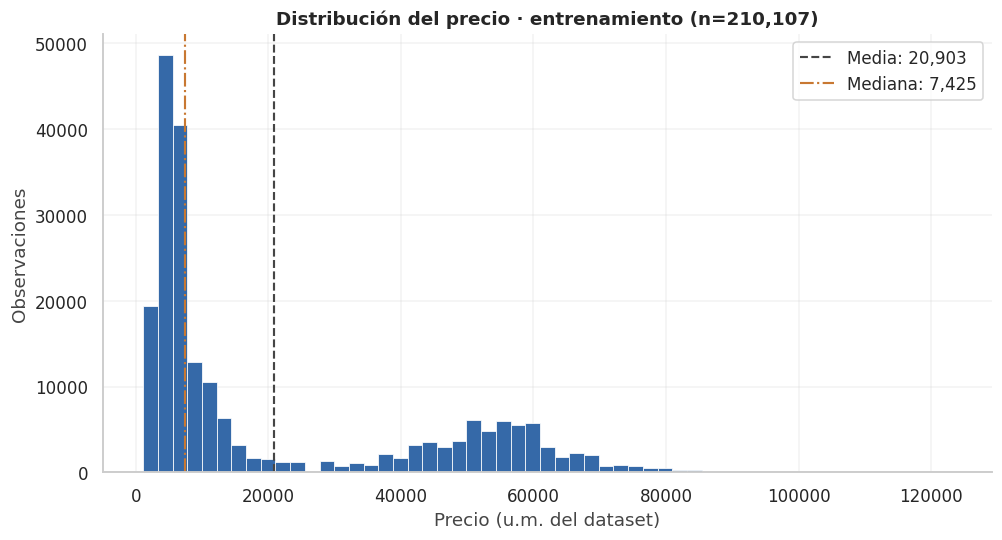

**Lectura:** el percentil 90 del precio es **57,920.00 u.m.** y su asimetría es **1.06**. Media, mediana y colas muestran que la distribución no es homogénea. **Recomendación:** no interpretar MAE como un porcentaje ni como garantía por billete; revisar también la magnitud cuadrática de los errores y los residuos del ganador.

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
ax.hist(y_train, bins=55, color=AZUL, edgecolor="white", linewidth=0.5)
ax.axvline(media_precio, color=GRIS, linestyle="--", linewidth=1.4, label=f"Media: {media_precio:,.0f}")
ax.axvline(mediana_precio, color=NARANJA, linestyle="-.", linewidth=1.4, label=f"Mediana: {mediana_precio:,.0f}")
ax.set(title=f"Distribución del precio · entrenamiento (n={len(eda):,})", xlabel="Precio (u.m. del dataset)", ylabel="Observaciones")
ax.legend()
guardar_figura(fig, "eda_histograma")
display(Markdown(
    f"**Lectura:** el percentil 90 del precio es **{y_train.quantile(.9):,.2f} u.m.** y su asimetría "
    f"es **{y_train.skew():.2f}**. Media, mediana y colas muestran que la distribución no es homogénea. "
    "**Recomendación:** no interpretar MAE como un porcentaje ni como garantía por billete; revisar también "
    "la magnitud cuadrática de los errores y los residuos del ganador."
))

### Dispersión: duración y precio · punto 8

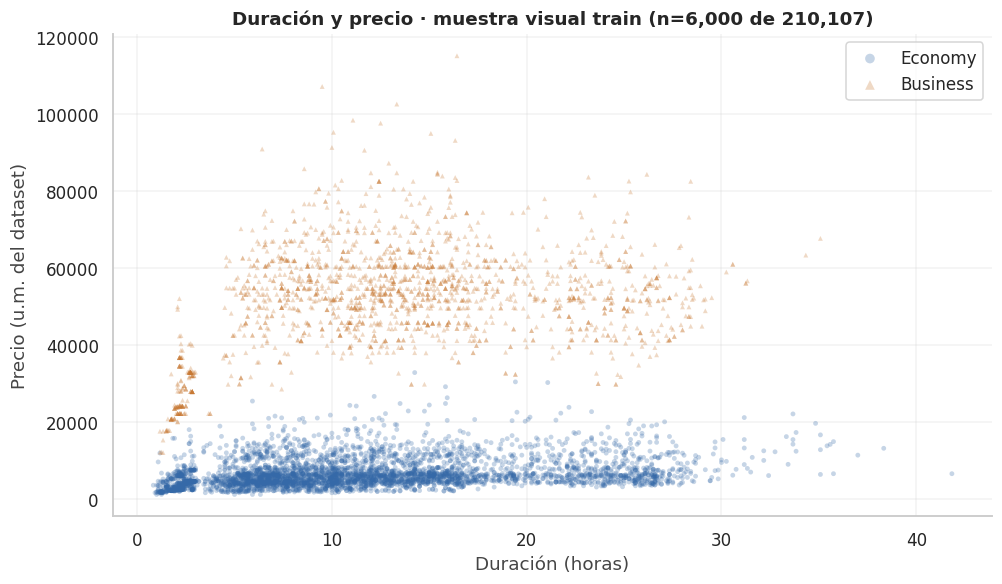

**Lectura:** la correlación lineal duración–precio calculada con **todo train** es **0.203**. La dispersión distingue clases de cabina y permite observar que una sola duración admite varios precios. **Recomendación:** modelar conjuntamente duración, cabina y ruta; una correlación global no separa sus efectos ni permite afirmar que prolongar un viaje causa un precio mayor.

In [12]:
muestra_visual = eda.sample(n=min(6000, len(eda)), random_state=SEED)
fig, ax = plt.subplots(figsize=(9, 5.2), layout="constrained")
for clase, color, marcador in [("Economy", AZUL, "o"), ("Business", NARANJA, "^")]:
    sub = muestra_visual.loc[muestra_visual["class"] == clase]
    ax.scatter(sub.duration, sub.price, s=10, alpha=.28, color=color, marker=marcador, label=clase, edgecolors="none")
ax.set(title=f"Duración y precio · muestra visual train (n={len(muestra_visual):,} de {len(eda):,})",
       xlabel="Duración (horas)", ylabel="Precio (u.m. del dataset)")
ax.legend(markerscale=2)
guardar_figura(fig, "eda_dispersion")
correlacion = eda.duration.corr(eda.price)
display(Markdown(
    f"**Lectura:** la correlación lineal duración–precio calculada con **todo train** es **{correlacion:.3f}**. "
    "La dispersión distingue clases de cabina y permite observar que una sola duración admite varios precios. "
    "**Recomendación:** modelar conjuntamente duración, cabina y ruta; una correlación global no separa "
    "sus efectos ni permite afirmar que prolongar un viaje causa un precio mayor."
))

### Boxplot: precios por cabina · punto 8

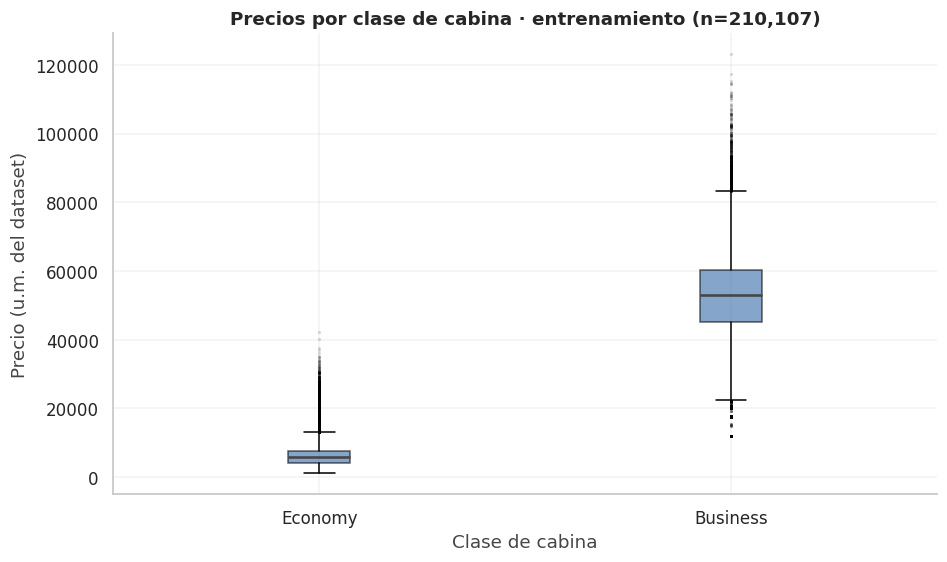

**Lectura:** la mediana es **5,772.00 u.m.** en Economy y **53,164.00 u.m.** en Business. Los puntos fuera de los bigotes son extremos según IQR dentro de su grupo; no son automáticamente errores. **Recomendación:** conservar precios plausibles y permitir relaciones no lineales e interacciones. Estos patrones apoyan comparar árboles y ensambles con el modelo lineal.

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5), layout="constrained")
ax.boxplot([eda.loc[eda['class'] == clase, 'price'] for clase in ["Economy", "Business"]],
           tick_labels=["Economy", "Business"], patch_artist=True,
           boxprops={"facecolor": AZUL, "alpha": .6}, medianprops={"color": GRIS, "linewidth": 1.7},
           flierprops={"marker": ".", "markersize": 2, "alpha": .15})
ax.set(title=f"Precios por clase de cabina · entrenamiento (n={len(eda):,})", xlabel="Clase de cabina", ylabel="Precio (u.m. del dataset)")
guardar_figura(fig, "eda_boxplot")
medianas_clase = eda.groupby("class").price.median()
display(Markdown(
    f"**Lectura:** la mediana es **{medianas_clase['Economy']:,.2f} u.m.** en Economy y "
    f"**{medianas_clase['Business']:,.2f} u.m.** en Business. Los puntos fuera de los bigotes son "
    "extremos según IQR dentro de su grupo; no son automáticamente errores. **Recomendación:** conservar "
    "precios plausibles y permitir relaciones no lineales e interacciones. Estos patrones apoyan comparar "
    "árboles y ensambles con el modelo lineal."
))

## 5. Preprocesamiento dentro de cada pipeline · puntos 9–10 y 12–13

- **Numéricas (`duration`, `days_left`):** imputación por mediana y `RobustScaler`, que resta la mediana y divide por IQR. Evita que horas o días dominen KNN solo por sus unidades. Los árboles no necesitan esta transformación, pero se conserva el mismo esquema para uniformar la comparación.
- **Categóricas:** imputación por moda y One-Hot con categorías aprendidas exclusivamente en train, `handle_unknown="ignore"` y salida densa. Se mantienen todos los indicadores en KNN y árboles: las categorías nominales tienen distancias simétricas. Solo la regresión lineal omite una categoría de referencia (`drop="first"`) para evitar colinealidad exacta con el intercepto. Una categoría desconocida se representa con ceros; se audita su frecuencia y se reconoce que esto no enseña al modelo el significado de una categoría nueva.
- `price` **no se imputa, escala ni codifica**. Cada pipeline aprende su preprocesamiento al ejecutar `fit(X_train, y_train)`. Validación, test y cada fold reciben `transform` usando únicamente los parámetros de su entrenamiento. Se usa la API de [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) y [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

La diferencia de codificación de la regresión lineal elimina redundancia, sin añadir información o usar otros conjuntos. Los coeficientes se interpretan respecto a su categoría base; no se comparan directamente con importancias de árboles.

| Variable categórica | Orden y justificación de One-Hot |
|---|---|
| `airline` | Aerolíneas nominales; asignar enteros inventaría jerarquía y distancias. |
| `source_city` | Ciudades nominales; no hay orden geográfico escalar válido. |
| `destination_city` | Igual que origen; One-Hot permite efectos distintos por destino. |
| `departure_time` | Franjas con ciclo diario; un orden lineal no representa proximidad entre medianoche y madrugada. |
| `arrival_time` | Franjas cíclicas; One-Hot evita imponer diferencias horarias no disponibles con precisión. |
| `stops` | Existe orden (`zero`, `one`, `two_or_more`), pero la última es un intervalo abierto; One-Hot no impone incrementos constantes de precio ni distancia. |
| `class` | Economy/Business tienen diferencia comercial, pero no una distancia numérica medida; la indicación binaria representa pertenencia. |

Las cardinalidades están reportadas en la auditoría; todas estas categorías son pequeñas frente a `flight`. No se usa Binary Encoding porque aquí no aporta una reducción necesaria de dimensión y complica la interpretación de bits y distancias. La ausencia observada de nulos evita eliminar datos: la mediana y moda quedan como políticas reproducibles dentro del pipeline ante valores faltantes futuros, no como una modificación artificial de esta versión completa.

In [14]:
def construir_preprocesador(lineal=False):
    numerico = Pipeline([
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalamiento", RobustScaler()),
    ])
    categorico = Pipeline([
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                 drop="first" if lineal else None)),
    ])
    return ColumnTransformer([
        ("numericas", numerico, NUMERICAS),
        ("categoricas", categorico, CATEGORICAS),
    ], remainder="drop")

estimadores = {
    "Lineal múltiple": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Árbol de decisión": DecisionTreeRegressor(random_state=SEED),
    "Random Forest": RandomForestRegressor(random_state=SEED, n_jobs=2),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
    "Referencia media": DummyRegressor(strategy="mean"),
}
OBLIGATORIOS = [nombre for nombre in estimadores if nombre != "Referencia media"]
pipelines = {
    nombre: Pipeline([("preprocesamiento", construir_preprocesador(lineal=nombre == "Lineal múltiple")),
                      ("modelo", estimador)])
    for nombre, estimador in estimadores.items()
}
parametros = {nombre: modelo.get_params(deep=False) for nombre, modelo in estimadores.items()}
display(pd.DataFrame([
    {"modelo": nombre, "parametros": json.dumps(params, ensure_ascii=False, default=str)}
    for nombre, params in parametros.items()
]))

,modelo,parametros
0,Lineal múltiple,"{""copy_X"": true, ""fit_intercept"": true, ""n_job..."
1,KNN,"{""algorithm"": ""auto"", ""leaf_size"": 30, ""metric..."
2,Árbol de decisión,"{""ccp_alpha"": 0.0, ""criterion"": ""squared_error..."
3,Random Forest,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""criteri..."
4,Gradient Boosting,"{""alpha"": 0.9, ""ccp_alpha"": 0.0, ""criterion"": ..."
5,Referencia media,"{""constant"": null, ""quantile"": null, ""strategy..."


## 6. Entrenamiento y evaluación en train/validación · puntos 14–15 y 18

Se usan las configuraciones iniciales de scikit-learn, salvo semillas y dos trabajadores en Random Forest para acotar recursos. No hay búsqueda de hiperparámetros. La referencia predice la **media de train**, útil para contextualizar MSE y R². Se registran por separado tiempo de ajuste y predicción de **todas** las filas.

**MAE:** promedio de errores absolutos, en u.m.; menor es mejor. **MSE:** promedio de errores al cuadrado, en u.m.²; penaliza más errores grandes. **R²:** proporción de variabilidad explicada frente a predecir una constante, sin unidades; 1 es ideal y puede ser negativo. Un R² alto no garantiza un MAE aceptable para una decisión económica.

Las métricas de train son de resustitución; KNN incluye cada observación entre sus vecinos y los árboles sin restricción pueden memorizar. Sirven para diagnosticar ajuste y se contrastan con validación.

In [15]:
def calcular_metricas(y_real, y_pred):
    assert np.isfinite(y_pred).all()
    return {"MAE": mean_absolute_error(y_real, y_pred),
            "MSE": mean_squared_error(y_real, y_pred), "R2": r2_score(y_real, y_pred)}

filas_metricas, filas_tiempos = [], []
predicciones = {}
for nombre, pipeline in pipelines.items():
    inicio = time.perf_counter()
    pipeline.fit(X_train, y_train)
    tiempo_ajuste = time.perf_counter() - inicio
    predicciones[nombre] = {}
    for conjunto, X_parte, y_parte in [("train", X_train, y_train), ("validacion", X_val, y_val)]:
        inicio_prediccion = time.perf_counter()
        pred = pipeline.predict(X_parte)
        tiempo_prediccion = time.perf_counter() - inicio_prediccion
        predicciones[nombre][conjunto] = pred
        filas_metricas.append({"modelo": nombre, "conjunto": conjunto, **calcular_metricas(y_parte, pred)})
        filas_tiempos.append({"modelo": nombre, "conjunto": conjunto, "filas_predichas": len(X_parte),
                             "ajuste_s": tiempo_ajuste, "prediccion_s": tiempo_prediccion})
    print(f"{nombre}: ajuste {tiempo_ajuste:.1f} s; train y validación completos.", flush=True)

metricas_desarrollo = pd.DataFrame(filas_metricas)
tiempos_desarrollo = pd.DataFrame(filas_tiempos)
comparativa = metricas_desarrollo.pivot(index="modelo", columns="conjunto", values=["MAE", "MSE", "R2"])
display(comparativa.loc[OBLIGATORIOS + ["Referencia media"]])
display(tiempos_desarrollo)
metricas_desarrollo.to_csv(REPORT_DIR / "regresion_metricas_desarrollo.csv", index=False)

Lineal múltiple: ajuste 0.5 s; train y validación completos.


KNN: ajuste 0.3 s; train y validación completos.


Árbol de decisión: ajuste 0.9 s; train y validación completos.


Random Forest: ajuste 21.1 s; train y validación completos.


Gradient Boosting: ajuste 13.4 s; train y validación completos.


Referencia media: ajuste 0.3 s; train y validación completos.


MAE                     MSE                  R2  \
conjunto                train  validacion       train  validacion   train   
modelo                                                                      
Lineal múltiple     4574.9671   4558.2940  4.5649e+07  4.5431e+07  0.9114   
KNN                 1385.9992   1769.0573  8.6244e+06  1.3651e+07  0.9833   
Árbol de decisión     50.2950   1190.6970  3.2364e+05  1.2375e+07  0.9994   
Random Forest        422.2006   1093.5790  1.2607e+06  7.5095e+06  0.9976   
Gradient Boosting   2937.7378   2931.0578  2.4523e+07  2.4316e+07  0.9524   
Referencia media   19769.0413  19769.5244  5.1538e+08  5.1604e+08  0.0000   

                               
conjunto           validacion  
modelo                         
Lineal múltiple    9.1196e-01  
KNN                9.7355e-01  
Árbol de decisión  9.7602e-01  
Random Forest      9.8545e-01  
Gradient Boosting  9.5288e-01  
Referencia media  -1.4663e-06

,modelo,conjunto,filas_predichas,ajuste_s,prediccion_s
0,Lineal múltiple,train,210107,0.4569,0.2301
1,Lineal múltiple,validacion,45023,0.4569,0.0500
2,KNN,train,210107,0.2971,27.9893
3,KNN,validacion,45023,0.2971,5.4387
4,Árbol de decisión,train,210107,0.8909,0.2023
5,Árbol de decisión,validacion,45023,0.8909,0.0429
6,Random Forest,train,210107,21.0798,1.7524
7,Random Forest,validacion,45023,21.0798,0.4145
8,Gradient Boosting,train,210107,13.4133,0.3303
9,Gradient Boosting,validacion,45023,13.4133,0.0693


### Comprobar el aislamiento del preprocesamiento · punto 13

**Confirmación explícita:** el código ejecuta `fit` de cada pipeline únicamente con `X_train`/`y_train`. `Pipeline.predict(X_val)` y `Pipeline.predict(X_test)` llaman internamente a `transform` en las transformaciones ya ajustadas; no vuelven a ajustarlas. Los asserts siguientes contrastan medianas y categorías aprendidas con train. En validación cruzada se clona el pipeline y cada `fit` se limita al subconjunto de entrenamiento de ese fold.

In [16]:
comprobaciones_preproceso = []
for nombre, pipeline in pipelines.items():
    pre = pipeline.named_steps["preprocesamiento"]
    mediana_ajustada = pre.named_transformers_["numericas"].named_steps["imputacion"].statistics_
    assert np.allclose(mediana_ajustada, X_train[NUMERICAS].median().values)
    escalador = pre.named_transformers_["numericas"].named_steps["escalamiento"]
    assert np.allclose(escalador.center_, X_train[NUMERICAS].median().values)
    encoder = pre.named_transformers_["categoricas"].named_steps["onehot"]
    for columna, categorias in zip(CATEGORICAS, encoder.categories_):
        assert set(categorias) == set(X_train[columna].dropna().unique())
    comprobaciones_preproceso.append({"modelo": nombre,
        "columnas_transformadas": len(pre.get_feature_names_out()),
        "medianas_y_categorias_solo_train": True})
display(pd.DataFrame(comprobaciones_preproceso))
desconocidas_val = pd.DataFrame([
    {"variable": c, "filas_categoria_desconocida_validacion": int((~X_val[c].isin(X_train[c].dropna())).sum())}
    for c in CATEGORICAS
])
display(desconocidas_val)

,modelo,columnas_transformadas,medianas_y_categorias_solo_train
0,Lineal múltiple,30,True
1,KNN,37,True
2,Árbol de decisión,37,True
3,Random Forest,37,True
4,Gradient Boosting,37,True
5,Referencia media,37,True


,variable,filas_categoria_desconocida_validacion
0,airline,0
1,source_city,0
2,departure_time,0
3,stops,0
4,arrival_time,0
5,destination_city,0
6,class,0


## 7. Comparación, sobreajuste y selección congelada · puntos 18, 20–21

Se elige el modelo obligatorio con **menor MAE de validación**. Para un empate numérico se desempata por menor MSE y después por nombre, de forma determinista. Los tiempos, interpretabilidad y brecha train–validación se usan para justificar la elección y discutir su coste, sin crear pesos arbitrarios después de observar test. La referencia nunca compite como ganador del taller.

Una brecha alta junto con error casi nulo en train sugiere sobreajuste. Error alto y parecido en ambos conjuntos, comparado con otros modelos, es compatible con subajuste. Estas son señales relativas; no existen umbrales universales de aceptación en el enunciado.

In [17]:
tabla_train = metricas_desarrollo.query("conjunto == 'train'").set_index("modelo")
tabla_val = metricas_desarrollo.query("conjunto == 'validacion'").set_index("modelo")
ranking_val = tabla_val.loc[OBLIGATORIOS].sort_values(["MAE", "MSE"], kind="stable").copy()
# El nombre fija el desempate exacto sin depender del orden del diccionario.
ranking_val = ranking_val.reset_index().sort_values(["MAE", "MSE", "modelo"]).set_index("modelo")
ganador = ranking_val.index[0]
seleccion_congelada = {"ganador": ganador, "criterio": "menor MAE de validación; desempate MSE y nombre",
                       "MAE_validacion": float(tabla_val.loc[ganador, "MAE"]),
                       "test_consultado": False, "semilla": SEED,
                       "parametros_ganador": parametros[ganador]}
(REPORT_DIR / "regresion_seleccion_congelada.json").write_text(
    json.dumps(seleccion_congelada, ensure_ascii=False, indent=2, default=str), encoding="utf-8"
)
brechas = pd.DataFrame({"MAE_train": tabla_train.MAE, "MAE_validacion": tabla_val.MAE})
brechas["brecha_absoluta"] = brechas.MAE_validacion - brechas.MAE_train
brechas["R2_validacion"] = tabla_val.R2
display(brechas.loc[OBLIGATORIOS].sort_values("MAE_validacion"))
display(ranking_val[["MAE", "MSE", "R2"]])
interpretabilidad = {
    "Lineal múltiple": "alta: coeficientes respecto a categorías de referencia, sin interpretación causal",
    "KNN": "intermedia: vecinos observados, pero sensible a escala y con predicción costosa",
    "Árbol de decisión": "intermedia: reglas legibles si el árbol es pequeño; un árbol profundo es difícil de inspeccionar",
    "Random Forest": "menor: combina muchos árboles; requiere herramientas adicionales para explicar predicciones",
    "Gradient Boosting": "menor: suma secuencial de árboles; las interacciones dificultan una explicación directa",
}
tiempo_ganador = tiempos_desarrollo.query("conjunto == 'train'").set_index("modelo").loc[ganador, "ajuste_s"]
mejora_referencia = 1 - tabla_val.loc[ganador, "MAE"] / tabla_val.loc["Referencia media", "MAE"]
display(Markdown(
    f"**Selección congelada: {ganador}.** MAE de validación **{tabla_val.loc[ganador, 'MAE']:,.2f} u.m.**, "
    f"MSE **{tabla_val.loc[ganador, 'MSE']:,.2f} u.m.²**, R² **{tabla_val.loc[ganador, 'R2']:.4f}**. "
    f"Su MAE es {mejora_referencia:.1%} menor que la referencia media. La brecha de MAE train–validación "
    f"es **{brechas.loc[ganador, 'brecha_absoluta']:,.2f} u.m.** y el ajuste tardó **{tiempo_ganador:.1f} s** "
    "en este equipo. Interpretabilidad " + interpretabilidad[ganador] + ". "
    "El menor error de validación justifica el ganador en este experimento; el tiempo medido y la dificultad "
    "de explicación son costes a contrastar con una necesidad real de servicio."
))
for nombre in OBLIGATORIOS:
    display(Markdown(
        f"- **{nombre}:** MAE train {tabla_train.loc[nombre, 'MAE']:,.2f} y validación "
        f"{tabla_val.loc[nombre, 'MAE']:,.2f}; brecha {brechas.loc[nombre, 'brecha_absoluta']:,.2f} u.m. "
        + ("El error de entrenamiento mucho menor indica capacidad de memorizar y exige cautela con el sobreajuste."
           if tabla_train.loc[nombre, 'MAE'] < .5 * tabla_val.loc[nombre, 'MAE']
           else "La brecha por sí sola no muestra una memorización extrema; comparar el nivel de error con los otros modelos.")))
display(Markdown(
    f"**Capacidad del modelo:** la regresión lineal alcanza MAE de validación "
    f"{tabla_val.loc['Lineal múltiple', 'MAE']:,.2f} u.m., frente a {tabla_val.loc[ganador, 'MAE']:,.2f} "
    "del ganador. Si sus errores de train y validación son altos y semejantes, la limitación es compatible "
    "con relaciones no lineales e interacciones que el modelo aditivo no representa. No se reajusta para esta entrega."
))

,MAE_train,MAE_validacion,brecha_absoluta,R2_validacion
modelo,,,,
Random Forest,422.2006,1093.5790,671.3784,0.9854
Árbol de decisión,50.2950,1190.6970,1140.4020,0.9760
KNN,1385.9992,1769.0573,383.0581,0.9735
Gradient Boosting,2937.7378,2931.0578,-6.6800,0.9529
Lineal múltiple,4574.9671,4558.2940,-16.6731,0.9120


,MAE,MSE,R2
modelo,,,
Random Forest,1093.5790,7.5095e+06,0.9854
Árbol de decisión,1190.6970,1.2375e+07,0.9760
KNN,1769.0573,1.3651e+07,0.9735
Gradient Boosting,2931.0578,2.4316e+07,0.9529
Lineal múltiple,4558.2940,4.5431e+07,0.9120


**Selección congelada: Random Forest.** MAE de validación **1,093.58 u.m.**, MSE **7,509,515.80 u.m.²**, R² **0.9854**. Su MAE es 94.5% menor que la referencia media. La brecha de MAE train–validación es **671.38 u.m.** y el ajuste tardó **21.1 s** en este equipo. Interpretabilidad menor: combina muchos árboles; requiere herramientas adicionales para explicar predicciones. El menor error de validación justifica el ganador en este experimento; el tiempo medido y la dificultad de explicación son costes a contrastar con una necesidad real de servicio.

- **Lineal múltiple:** MAE train 4,574.97 y validación 4,558.29; brecha -16.67 u.m. La brecha por sí sola no muestra una memorización extrema; comparar el nivel de error con los otros modelos.

- **KNN:** MAE train 1,386.00 y validación 1,769.06; brecha 383.06 u.m. La brecha por sí sola no muestra una memorización extrema; comparar el nivel de error con los otros modelos.

- **Árbol de decisión:** MAE train 50.29 y validación 1,190.70; brecha 1,140.40 u.m. El error de entrenamiento mucho menor indica capacidad de memorizar y exige cautela con el sobreajuste.

- **Random Forest:** MAE train 422.20 y validación 1,093.58; brecha 671.38 u.m. El error de entrenamiento mucho menor indica capacidad de memorizar y exige cautela con el sobreajuste.

- **Gradient Boosting:** MAE train 2,937.74 y validación 2,931.06; brecha -6.68 u.m. La brecha por sí sola no muestra una memorización extrema; comparar el nivel de error con los otros modelos.

**Capacidad del modelo:** la regresión lineal alcanza MAE de validación 4,558.29 u.m., frente a 1,093.58 del ganador. Si sus errores de train y validación son altos y semejantes, la limitación es compatible con relaciones no lineales e interacciones que el modelo aditivo no representa. No se reajusta para esta entrega.

### Lectura de sesgo, varianza y coste observados

La regresión lineal tiene errores parecidos en train (4.574,97) y validación (4.558,29 u.m.), pero ambos son bastante mayores que los de Random Forest: es evidencia compatible con subajuste de una relación aditiva. Gradient Boosting con sus parámetros iniciales también mantiene errores semejantes (2.937,74 y 2.931,06 u.m.), aunque representa mejor algunas relaciones no lineales. KNN aumenta de 1.386,00 a 1.769,06 u.m.; sus métricas de train se favorecen por incluir el propio punto y predecir todas esas filas tomó 79,28 s en esta ejecución, pese a que ajustarlo fue rápido.

El árbol reduce MAE de train a 50,29 u.m. pero sube a 1.190,70 en validación: la memorización es clara. Random Forest pasa de 422,20 a 1.093,58 u.m.; promediar muchos árboles disminuye el error de validación frente al árbol individual, aunque conserva brecha y no elimina todo sobreajuste. Ajustó en 21,47 s frente a 0,86 s del árbol y ofrece menor facilidad de explicación. Se acepta ese coste en el ejercicio porque logra el menor MAE sin usar test para decidir. Los tiempos corresponden al equipo de esta ejecución.

## 8. Apertura única de test · puntos 22–23

Se evalúan **los cinco regresores y la referencia**, manteniendo parámetros, objetos ya ajustados y ganador. No se reentrena con train + validación y no se cambia la elección a partir del ranking de test. Las diferencias de ranking pueden surgir por la variabilidad de las particiones; no convierten test en otro conjunto para seleccionar modelos.

In [18]:
assert seleccion_congelada["test_consultado"] is False
ganador_antes_test = ganador
for nombre, pipeline in pipelines.items():
    inicio = time.perf_counter()
    pred = pipeline.predict(X_test)
    segundos = time.perf_counter() - inicio
    predicciones[nombre]["test"] = pred
    filas_metricas.append({"modelo": nombre, "conjunto": "test", **calcular_metricas(y_test, pred)})
    filas_tiempos.append({"modelo": nombre, "conjunto": "test", "filas_predichas": len(X_test),
                         "ajuste_s": np.nan, "prediccion_s": segundos})
metricas = pd.DataFrame(filas_metricas)
tiempos = pd.DataFrame(filas_tiempos)
tabla_test = metricas.query("conjunto == 'test'").set_index("modelo")
display(tabla_test.loc[OBLIGATORIOS + ["Referencia media"], ["MAE", "MSE", "R2"]].sort_values("MAE"))
ranking_test = tabla_test.loc[OBLIGATORIOS].reset_index().sort_values(["MAE", "MSE", "modelo"]).set_index("modelo")
rangos = pd.DataFrame({"MAE_validacion": tabla_val.loc[OBLIGATORIOS, "MAE"],
                       "MAE_test": tabla_test.loc[OBLIGATORIOS, "MAE"]})
rangos["puesto_validacion"] = rangos.MAE_validacion.rank(method="min").astype(int)
rangos["puesto_test"] = rangos.MAE_test.rank(method="min").astype(int)
rangos["cambio_MAE_test_menos_val"] = rangos.MAE_test - rangos.MAE_validacion
display(rangos.sort_values("puesto_validacion"))
assert ganador == ganador_antes_test
display(Markdown(
    f"**Generalización del ganador congelado:** {ganador} obtiene MAE de test "
    f"**{tabla_test.loc[ganador, 'MAE']:,.2f} u.m.**, R² **{tabla_test.loc[ganador, 'R2']:.4f}** y "
    f"un cambio de MAE de **{rangos.loc[ganador, 'cambio_MAE_test_menos_val']:+,.2f} u.m.** respecto a validación. "
    f"El primer puesto descriptivo en test es **{ranking_test.index[0]}**. "
    + ("Coincide con la selección de validación, lo que respalda su estabilidad en estas dos particiones. "
       if ranking_test.index[0] == ganador else
       "El orden difiere de validación; se conserva la selección original para evitar optimismo por reutilizar test. ")
    + "Las particiones aleatorias contienen observaciones distintas y no garantizan idéntica mezcla de casos difíciles. "
      "Una sola partición no demuestra superioridad estadística ni transferencia temporal."
))

,MAE,MSE,R2
modelo,,,
Random Forest,1097.8574,7.7579e+06,9.8489e-01
Árbol de decisión,1190.0922,1.2731e+07,9.7520e-01
KNN,1787.6947,1.4092e+07,9.7255e-01
Gradient Boosting,2954.4506,2.5064e+07,9.5118e-01
Lineal múltiple,4556.7027,4.5659e+07,9.1107e-01
Referencia media,19740.6167,5.1343e+08,-7.0555e-06


,MAE_validacion,MAE_test,puesto_validacion,puesto_test,cambio_MAE_test_menos_val
modelo,,,,,
Random Forest,1093.5790,1097.8574,1,1,4.2785
Árbol de decisión,1190.6970,1190.0922,2,2,-0.6048
KNN,1769.0573,1787.6947,3,3,18.6373
Gradient Boosting,2931.0578,2954.4506,4,4,23.3928
Lineal múltiple,4558.2940,4556.7027,5,5,-1.5913


**Generalización del ganador congelado:** Random Forest obtiene MAE de test **1,097.86 u.m.**, R² **0.9849** y un cambio de MAE de **+4.28 u.m.** respecto a validación. El primer puesto descriptivo en test es **Random Forest**. Coincide con la selección de validación, lo que respalda su estabilidad en estas dos particiones. Las particiones aleatorias contienen observaciones distintas y no garantizan idéntica mezcla de casos difíciles. Una sola partición no demuestra superioridad estadística ni transferencia temporal.

## 9. Validación cruzada del ganador · puntos 24–25 y 27

K-Fold divide las filas en cinco partes: ajusta con cuatro y evalúa con la restante, repitiendo hasta que cada parte haya sido evaluada una vez. Promediar las cinco evaluaciones reduce la dependencia de una única partición afortunada y permite observar dispersión; no sustituye test ni elimina sesgos compartidos por todas las filas. Véase la [guía de validación cruzada de scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html).

Se aplica **`KFold(n_splits=5, shuffle=True, random_state=42)` exclusivamente sobre train**, usando un clon del pipeline completo del ganador. En cada fold se vuelven a aprender imputación, escalamiento, categorías y estimador. La selección ya está congelada; estos resultados miden variación, no desencadenan un ajuste adicional. Los folds entrenan con aproximadamente el 80 % de train, menos filas que el modelo de la evaluación holdout.

scikit-learn devuelve MAE y MSE con signo negativo porque su API maximiza puntuaciones; se invierte el signo al reportar. La desviación estándar entre folds describe dispersión y **no es un intervalo de confianza**.

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
splits_cv = list(cv.split(X_train, y_train))
for idx_fit, idx_eval in splits_cv:
    assert not set(idx_fit) & set(idx_eval)
    assert len(idx_fit) + len(idx_eval) == len(X_train)
inicio_cv = time.perf_counter()
resultados_cv = cross_validate(
    clone(pipelines[ganador]), X_train, y_train, cv=splits_cv,
    scoring={"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error", "R2": "r2"},
    n_jobs=1, error_score="raise", return_train_score=False,
)
tiempo_cv = time.perf_counter() - inicio_cv
tabla_cv = pd.DataFrame({
    "fold": np.arange(1, 6), "filas_ajuste": [len(a) for a, b in splits_cv],
    "filas_evaluacion": [len(b) for a, b in splits_cv],
    "MAE": -resultados_cv["test_MAE"], "MSE": -resultados_cv["test_MSE"],
    "R2": resultados_cv["test_R2"], "ajuste_s": resultados_cv["fit_time"],
    "evaluacion_s": resultados_cv["score_time"],
})
resumen_cv = tabla_cv[["MAE", "MSE", "R2"]].agg(["mean", "std"]).rename(index={"mean": "media", "std": "desviacion_estandar"}).T
resumen_cv["validacion_holdout"] = tabla_val.loc[ganador, ["MAE", "MSE", "R2"]].astype(float)
display(tabla_cv)
display(resumen_cv)
display(Markdown(
    f"**Estabilidad:** {ganador} tiene MAE de CV **{resumen_cv.loc['MAE', 'media']:,.2f} ± "
    f"{resumen_cv.loc['MAE', 'desviacion_estandar']:,.2f} u.m.** (media ± desviación estándar de cinco folds), "
    f"frente a **{tabla_val.loc[ganador, 'MAE']:,.2f} u.m.** en validación holdout. "
    f"La dispersión relativa de MAE es **{resumen_cv.loc['MAE', 'desviacion_estandar'] / resumen_cv.loc['MAE', 'media']:.1%}**. "
    "Diferencias entre CV y holdout pueden deberse a composición de las particiones y cantidad de datos de ajuste; "
    f"no se modifica el ganador. La validación cruzada tomó **{tiempo_cv:.1f} s** en este entorno."
))

,fold,filas_ajuste,filas_evaluacion,MAE,MSE,R2,ajuste_s,evaluacion_s
0,1,168085,42022,1133.8064,7.9027e+06,0.9846,16.7203,0.3731
1,2,168085,42022,1141.5715,7.9333e+06,0.9846,16.9703,0.3739
2,3,168086,42021,1116.4643,7.6762e+06,0.9852,16.7766,0.3952
3,4,168086,42021,1122.3222,7.6007e+06,0.9852,16.8151,0.3713
4,5,168086,42021,1117.0978,7.5584e+06,0.9853,16.8292,0.3729


,media,desviacion_estandar,validacion_holdout
MAE,1.1263e+03,11.0318,1.0936e+03
MSE,7.7343e+06,173278.2539,7.5095e+06
R2,9.8499e-01,0.0003,9.8545e-01


**Estabilidad:** Random Forest tiene MAE de CV **1,126.25 ± 11.03 u.m.** (media ± desviación estándar de cinco folds), frente a **1,093.58 u.m.** en validación holdout. La dispersión relativa de MAE es **1.0%**. Diferencias entre CV y holdout pueden deberse a composición de las particiones y cantidad de datos de ajuste; no se modifica el ganador. La validación cruzada tomó **86.1 s** en este entorno.

### Interpretación de la comparación CV–validación · punto 27

El MAE medio de CV **empeora en 32.67 u.m. (2.99%)** respecto a la validación original. Cada fold usa menos filas de ajuste que el modelo holdout; además cambia la composición de casos. La desviación de **11.03 u.m.** equivale a **0.98%** de la media: la variación entre estos cinco folds es pequeña respecto al error promedio, lo que respalda estabilidad bajo este reparto aleatorio. Esto no prueba estabilidad temporal ni sustituye una evaluación externa. El pequeño cambio de test frente a validación y la CV algo más exigente son compatibles con un rendimiento similar dentro de este origen de datos; no se modifica el ganador.

## 10. Síntesis gráfica 2×2 y diagnóstico final · punto 28

Los dos paneles de error comparan todos los modelos obligatorios sobre conjuntos completos. Las dispersiones del ganador usan una muestra visual reproducible de test para mostrar calibración y residuos; las métricas anteriores permanecen calculadas con todas sus filas. La diagonal representa predicción perfecta y la línea de cero indica ausencia de error firmado.

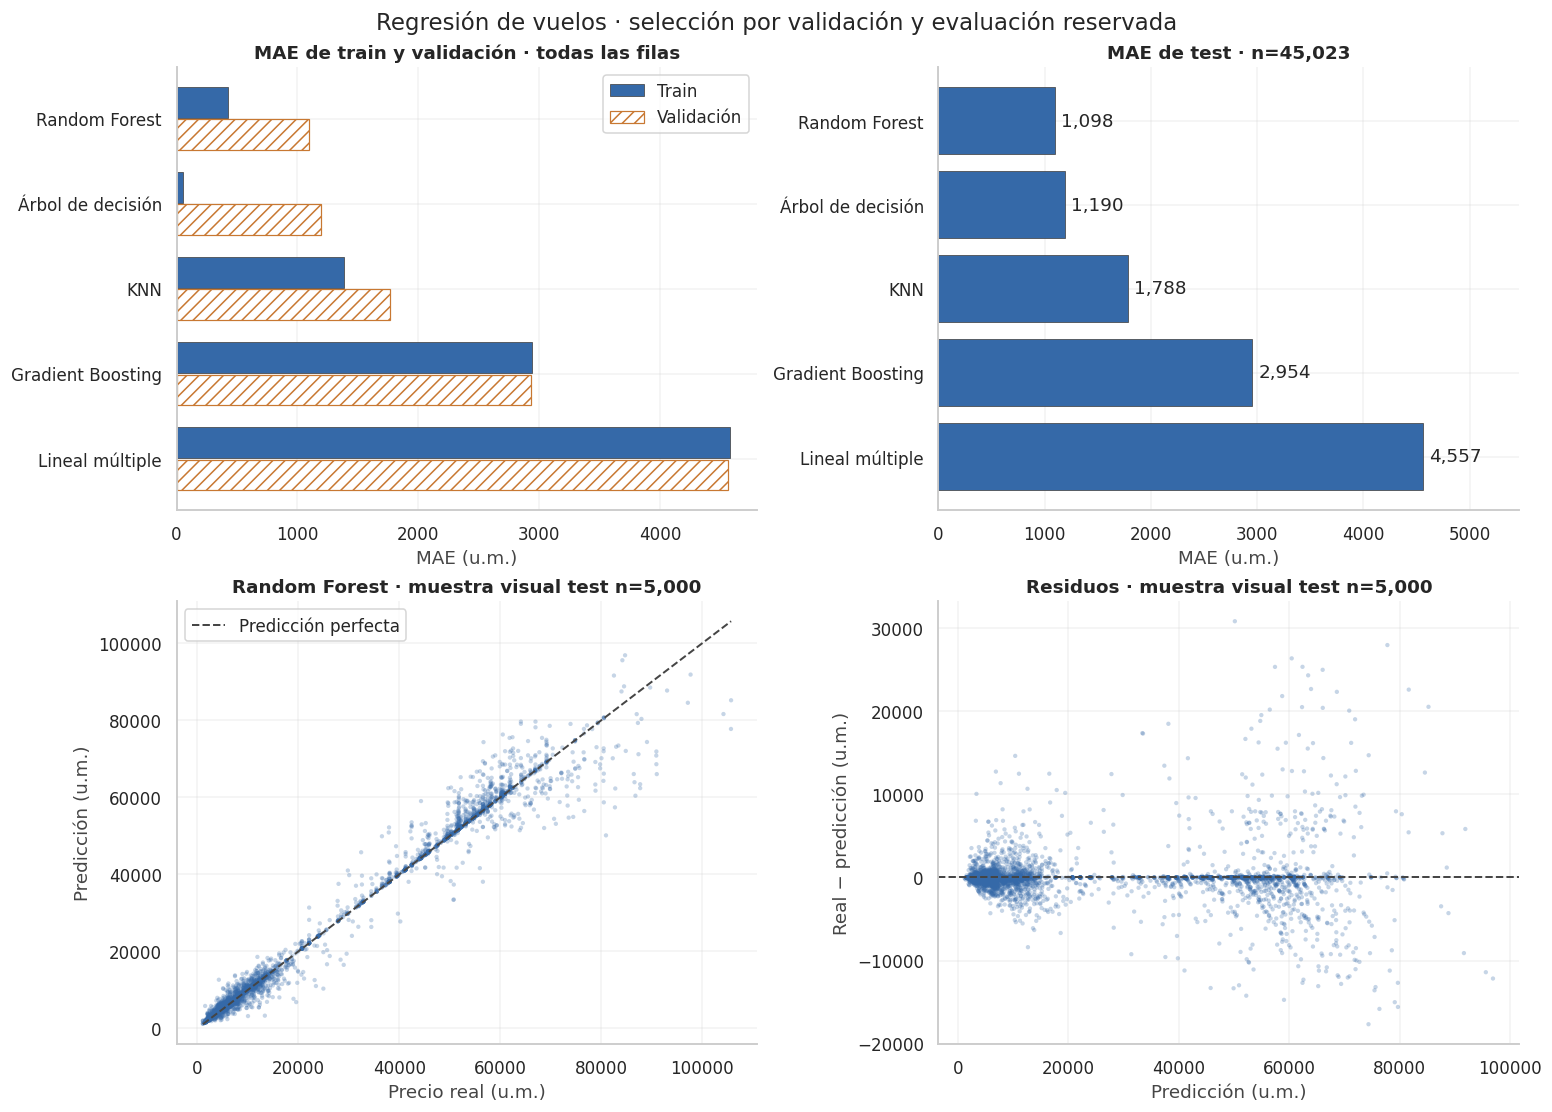

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
orden = ranking_val.index.tolist()
posiciones = np.arange(len(orden))
axs[0, 0].barh(posiciones - .19, tabla_train.loc[orden, "MAE"], height=.36,
               color=AZUL, label="Train", edgecolor=GRIS, linewidth=.5)
axs[0, 0].barh(posiciones + .19, tabla_val.loc[orden, "MAE"], height=.36,
               color="white", hatch="///", edgecolor=NARANJA, label="Validación", linewidth=.8)
axs[0, 0].set(yticks=posiciones, yticklabels=orden, xlabel="MAE (u.m.)", title="MAE de train y validación · todas las filas")
axs[0, 0].invert_yaxis()
axs[0, 0].legend(loc="upper right")
axs[0, 1].barh(orden, tabla_test.loc[orden, "MAE"], color=AZUL, edgecolor=GRIS, linewidth=.5)
axs[0, 1].set(xlabel="MAE (u.m.)", title=f"MAE de test · n={len(X_test):,}")
axs[0, 1].set_xlim(0, tabla_test.loc[orden, "MAE"].max() * 1.2)
axs[0, 1].bar_label(axs[0, 1].containers[0], labels=[f"{v:,.0f}" for v in tabla_test.loc[orden, "MAE"]], padding=4)
axs[0, 1].invert_yaxis()
indices_vis = np.random.default_rng(SEED).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
reales_vis = y_test.to_numpy()[indices_vis]
pred_vis = predicciones[ganador]["test"][indices_vis]
axs[1, 0].scatter(reales_vis, pred_vis, s=8, alpha=.28, color=AZUL, edgecolors="none")
extremos = [min(reales_vis.min(), pred_vis.min()), max(reales_vis.max(), pred_vis.max())]
axs[1, 0].plot(extremos, extremos, color=GRIS, linestyle="--", linewidth=1.3, label="Predicción perfecta")
axs[1, 0].set(xlabel="Precio real (u.m.)", ylabel="Predicción (u.m.)", title=f"{ganador} · muestra visual test n={len(indices_vis):,}")
axs[1, 0].legend()
axs[1, 1].scatter(pred_vis, reales_vis - pred_vis, s=8, alpha=.28, color=AZUL, edgecolors="none")
axs[1, 1].axhline(0, color=GRIS, linestyle="--", linewidth=1.3)
axs[1, 1].set(xlabel="Predicción (u.m.)", ylabel="Real − predicción (u.m.)", title=f"Residuos · muestra visual test n={len(indices_vis):,}")
fig.suptitle("Regresión de vuelos · selección por validación y evaluación reservada", fontsize=15)
guardar_figura(fig, "sintesis_2x2")

### Errores por clase y valores predichos

In [21]:
diagnostico_test = X_test[["class", "airline"]].copy()
diagnostico_test["real"] = y_test
diagnostico_test["predicho"] = predicciones[ganador]["test"]
diagnostico_test["error_absoluto"] = abs(diagnostico_test.real - diagnostico_test.predicho)
diagnostico_test["residuo"] = diagnostico_test.real - diagnostico_test.predicho
errores_cabina = diagnostico_test.groupby("class").agg(
    observaciones=("real", "size"), MAE=("error_absoluto", "mean"),
    mediana_error_absoluto=("error_absoluto", "median"), sesgo_medio=("residuo", "mean"))
display(errores_cabina)
negativas = pd.DataFrame([
    {"modelo": nombre, "predicciones_negativas_test": int((predicciones[nombre]["test"] < 0).sum())}
    for nombre in OBLIGATORIOS
])
display(negativas)
display(Markdown(
    f"**Diagnóstico descriptivo:** el percentil 90 del error absoluto del ganador es "
    f"**{diagnostico_test.error_absoluto.quantile(.9):,.2f} u.m.**, frente a MAE "
    f"**{tabla_test.loc[ganador, 'MAE']:,.2f} u.m.**. La tabla permite contrastar cabinas, sin atribuir "
    "causalidad a la clase. Una predicción negativa sería incompatible con un precio, pero no se recorta "
    "después de mirar test: se registra como limitación del modelo original. Cualquier corrección futura "
    "requeriría un nuevo experimento con evaluación reservada."
))

,observaciones,MAE,mediana_error_absoluto,sesgo_medio
class,,,,
Business,14009,2151.8455,197.200,-17.3963
Economy,31014,621.7718,176.465,-35.5119


,modelo,predicciones_negativas_test
0,Lineal múltiple,2593
1,KNN,0
2,Árbol de decisión,0
3,Random Forest,0
4,Gradient Boosting,0


**Diagnóstico descriptivo:** el percentil 90 del error absoluto del ganador es **3,079.11 u.m.**, frente a MAE **1,097.86 u.m.**. La tabla permite contrastar cabinas, sin atribuir causalidad a la clase. Una predicción negativa sería incompatible con un precio, pero no se recorta después de mirar test: se registra como limitación del modelo original. Cualquier corrección futura requeriría un nuevo experimento con evaluación reservada.

## 11. Conclusiones y preguntas abiertas · punto 28

In [22]:
display(Markdown(
    f"**Resultado del problema de vuelos.** El modelo elegido exclusivamente en validación fue **{ganador}**. "
    f"Su MAE pasó de **{tabla_val.loc[ganador, 'MAE']:,.2f} u.m.** en validación a "
    f"**{tabla_test.loc[ganador, 'MAE']:,.2f} u.m.** en test, con R² de test "
    f"**{tabla_test.loc[ganador, 'R2']:.4f}**. En validación cruzada sobre train, su MAE fue "
    f"**{resumen_cv.loc['MAE', 'media']:,.2f} ± {resumen_cv.loc['MAE', 'desviacion_estandar']:,.2f} u.m.**. "
    "Estas cifras sustentan la comparación dentro de este dataset, sin establecer todavía un umbral de utilidad comercial.\n\n"
    "**Relación con el problema tiroideo.** Ambos notebooks separan conjuntos antes del EDA que guía decisiones "
    "y ajustan transformaciones dentro de pipelines. En vuelos importa la magnitud de un error continuo "
    "(MAE y MSE); en recurrencia importa distinguir casos positivos y negativos (Recall, Precision, F1 y "
    "matriz de confusión). Por eso MAE de vuelos y Recall tiroideo no se comparan numéricamente. Vuelos tiene "
    "muchas más observaciones; el dataset tiroideo es pequeño y requiere particiones por perfiles idénticos, "
    "por lo que cambios de pocos pacientes pueden cambiar sus métricas. El rendimiento predictivo clínico "
    "no equivale a validación para uso asistencial.\n\n"
    "**Límites.** La partición aleatoria puede compartir rutas y configuraciones, no reproduce un despliegue "
    "en el futuro y no demuestra transferencia a otras ciudades o aerolíneas. Se excluyeron códigos de vuelo; "
    "la distribución de precios reúne cabinas diferentes. El MAE agregado oculta errores individuales grandes "
    "y no informa por sí solo un porcentaje de error. No se exploraron hiperparámetros ni incertidumbre "
    "predictiva. En el problema tiroideo, excluir `Response` reduce un riesgo evidente de información posterior "
    "al tratamiento, pero sigue existiendo incertidumbre sobre cuándo se midieron otras variables clínicas.\n\n"
    "**Preguntas abiertas.** ¿Cómo cambia el desempeño al evaluar por fecha futura o por ruta no vista? "
    "¿Qué MAE y latencia serían aceptables para una decisión real? ¿Cómo se distribuyen los errores entre "
    "aerolíneas y franjas? ¿Puede una fuente con fechas permitir una evaluación temporal? En tiroides, "
    "¿se pueden verificar los momentos de medición y validar en otra cohorte? Estas preguntas requieren "
    "datos o experimentos nuevos y no se resuelven reutilizando test."
))

**Resultado del problema de vuelos.** El modelo elegido exclusivamente en validación fue **Random Forest**. Su MAE pasó de **1,093.58 u.m.** en validación a **1,097.86 u.m.** en test, con R² de test **0.9849**. En validación cruzada sobre train, su MAE fue **1,126.25 ± 11.03 u.m.**. Estas cifras sustentan la comparación dentro de este dataset, sin establecer todavía un umbral de utilidad comercial.

**Relación con el problema tiroideo.** Ambos notebooks separan conjuntos antes del EDA que guía decisiones y ajustan transformaciones dentro de pipelines. En vuelos importa la magnitud de un error continuo (MAE y MSE); en recurrencia importa distinguir casos positivos y negativos (Recall, Precision, F1 y matriz de confusión). Por eso MAE de vuelos y Recall tiroideo no se comparan numéricamente. Vuelos tiene muchas más observaciones; el dataset tiroideo es pequeño y requiere particiones por perfiles idénticos, por lo que cambios de pocos pacientes pueden cambiar sus métricas. El rendimiento predictivo clínico no equivale a validación para uso asistencial.

**Límites.** La partición aleatoria puede compartir rutas y configuraciones, no reproduce un despliegue en el futuro y no demuestra transferencia a otras ciudades o aerolíneas. Se excluyeron códigos de vuelo; la distribución de precios reúne cabinas diferentes. El MAE agregado oculta errores individuales grandes y no informa por sí solo un porcentaje de error. No se exploraron hiperparámetros ni incertidumbre predictiva. En el problema tiroideo, excluir `Response` reduce un riesgo evidente de información posterior al tratamiento, pero sigue existiendo incertidumbre sobre cuándo se midieron otras variables clínicas.

**Preguntas abiertas.** ¿Cómo cambia el desempeño al evaluar por fecha futura o por ruta no vista? ¿Qué MAE y latencia serían aceptables para una decisión real? ¿Cómo se distribuyen los errores entre aerolíneas y franjas? ¿Puede una fuente con fechas permitir una evaluación temporal? En tiroides, ¿se pueden verificar los momentos de medición y validar en otra cohorte? Estas preguntas requieren datos o experimentos nuevos y no se resuelven reutilizando test.

## Comparación conjunta de los dos problemas · punto 28

Esta comparación resume la **ejecución entregada**, con semilla 42 y las versiones fijadas. Cada notebook entrena de forma independiente; no utiliza resultados del otro para seleccionar modelos. Consulte [regresión](01_regresion_vuelos.ipynb) y [clasificación](02_clasificacion_tiroides.ipynb) para todas las tablas.

| Aspecto | Vuelos | Recurrencia tiroidea |
|---|---|---|
| Registros analizados | 300,153 | 364 tras 19 duplicados completos |
| Modelo elegido en validación | **Random Forest** | **Gradient Boosting** |
| Validación | MAE **1,093.58 u.m.**, R² 0.9854 | Recall **0.786**, F1 0.815 |
| Test | MAE **1,097.86 u.m.**, R² 0.9849 | Recall **0.800**, F1 0.857 |
| CV del ganador, solo train | MAE **1,126.25 ± 11.03 u.m.** | Recall **0.771 ± 0.089** |

**Qué funcionó y por qué.** En vuelos, Random Forest puede representar interacciones entre cabina, aerolínea, ruta, duración y anticipación. Promediar árboles reduce la varianza frente al árbol individual: el árbol tuvo MAE de validación 1.190,70 u.m. frente a 1.093,58 del bosque. La regresión lineal obtuvo 4.558,29 u.m.; su forma aditiva resulta más limitada en esta comparación. En tiroides, Gradient Boosting combina árboles de manera secuencial para corregir errores. Empató con Random Forest en Recall, F1 y Precision de validación y se eligió por su menor brecha absoluta de F1 entre train y validación. Es una elección entre las configuraciones probadas, no una superioridad universal del algoritmo. El escalamiento es relevante para KNN y el ajuste numérico lineal; no explica por sí solo el desempeño de los árboles.

**Generalización y estabilidad.** El MAE de vuelos cambió poco entre validación y test. La CV de recurrencia presenta una variación de Recall de casi nueve puntos porcentuales entre folds, acorde con una muestra pequeña y heterogénea. En el test tiroideo hay solo 15 recurrencias: un caso cambia el Recall aproximadamente 6,7 puntos porcentuales. Random Forest logró Recall 0,867 y F1 0,867 en test, superiores al ganador congelado; se reporta esa diferencia sin reseleccionar con test. MAE, R² y F1 miden cosas distintas y no permiten ordenar la dificultad de ambos problemas en una escala común.

**Limpieza y límites.** Las decisiones más importantes metodológicamente fueron retirar índice/código de vuelo, conservar precios extremos plausibles y, en tiroides, excluir la respuesta al tratamiento y mantener juntos los perfiles repetidos. Esto delimita mejor qué información puede usar el modelo. No se realizó una ablación, por lo que no se atribuye una mejora numérica causal a una operación de limpieza. Quedan abiertas la generalización temporal de vuelos, la utilidad de conservar el código con otro encoding, la cronología de las variables clínicas y la evaluación tiroidea con más pacientes identificables. El IQR tiroideo se aplica a edad y a un conteo derivado de campos de antecedentes afirmativos, solo en el EDA. En este último, IQR cero señala 22 valores válidos que se conservan; la adaptación no añade predictores ni implica que ambos antecedentes tengan igual importancia clínica.


## 12. Verificación, archivos y sustentación

Las comprobaciones siguientes fallan explícitamente si hay métricas ausentes, particiones inconsistentes o un cambio del ganador. Los CSV conservan los resultados con su precisión numérica; las figuras se guardan como PNG. No se serializan los bosques completos para evitar un archivo de entrega innecesariamente grande: el notebook permite reconstruirlos.

In [23]:
assert len(metricas) == len(estimadores) * 3
assert not metricas.duplicated(["modelo", "conjunto"]).any()
assert set(metricas.conjunto) == {"train", "validacion", "test"}
assert np.isfinite(metricas[["MAE", "MSE", "R2"]].to_numpy()).all()
assert (metricas[["MAE", "MSE"]] >= 0).all().all()
assert len(tabla_cv) == 5 and np.isfinite(tabla_cv[["MAE", "MSE", "R2"]].to_numpy()).all()
assert ganador == seleccion_congelada["ganador"]
assert all(len(predicciones[nombre]["test"]) == len(X_test) for nombre in estimadores)
assert len(datos) == 300153, "La versión verificada debe conservar las 300153 filas."
assert not indices["test"] & indices["train"]

metricas.to_csv(REPORT_DIR / "regresion_metricas.csv", index=False)
export_pred = pd.DataFrame({"fila_limpia": X_test.index, "y_true": y_test.to_numpy()})
for nombre in OBLIGATORIOS + ["Referencia media"]:
    export_pred[nombre] = predicciones[nombre]["test"]
export_pred.to_csv(REPORT_DIR / "regresion_predicciones_test.csv", index=False)
tiempos.to_csv(REPORT_DIR / "regresion_tiempos.csv", index=False)
tabla_cv.to_csv(REPORT_DIR / "regresion_cv_folds.csv", index=False)
resumen_cv.to_csv(REPORT_DIR / "regresion_cv_resumen.csv", index_label="metrica")
rangos.to_csv(REPORT_DIR / "regresion_ranking.csv", index_label="modelo")
errores_cabina.to_csv(REPORT_DIR / "regresion_errores_cabina_test.csv", index_label="clase")
resumen = {
    "fuente": fuente, "python": platform.python_version(),
    "dependencias": {p: version(p) for p in DEPENDENCIAS}, "semilla": SEED,
    "filas_limpias": len(datos), "particiones": particiones.to_dict(orient="records"),
    "ganador_validacion": ganador, "criterio_seleccion": seleccion_congelada["criterio"],
    "metricas_ganador_validacion": tabla_val.loc[ganador, ["MAE", "MSE", "R2"]].to_dict(),
    "metricas_ganador_test": tabla_test.loc[ganador, ["MAE", "MSE", "R2"]].to_dict(),
    "cv": resumen_cv.reset_index(names="metrica").to_dict(orient="records"),
    "tiempo_cv_segundos": tiempo_cv, "parametros_modelos": parametros,
    "validaciones": {"particiones_disjuntas": True, "preprocesamiento_solo_train": True,
                     "test_no_usado_para_seleccion": True, "metricas_completas_finitas": True,
                     "sin_muestreo_en_modelado_o_metricas": True},
}
(REPORT_DIR / "regresion_resumen.json").write_text(
    json.dumps(resumen, indent=2, ensure_ascii=False, default=str), encoding="utf-8"
)
print("Verificaciones completas. Resultados en:", REPORT_DIR)
print("Figuras en:", FIG_DIR)

Verificaciones completas. Resultados en: S:\Github\Workshop_1\workshop_2\reportes
Figuras en: S:\Github\Workshop_1\workshop_2\figuras


### Lista de comprobación de los puntos 1–28

| Punto | Evidencia en este notebook |
|---|---|
| 1 | Fuente, descarga, huella y carga de `Clean_Dataset.csv`. |
| 2 | `head`, `tail`, `shape`, `info` y diccionario de variables. |
| 3 | `.describe()` de train e interpretación de tres estadísticos. |
| 4 | Nulos absolutos/porcentuales y política de imputación en pipeline. |
| 5 | Duplicados y comparación antes/después. |
| 6 | Auditoría de espacios, etiquetas y mayúsculas; corrección determinista. |
| 7 | IQR en `duration` y `price`, sin eliminar extremos plausibles. |
| 8 | Barras, pie, histograma, dispersión y boxplot. |
| 9 | Justificación de One-Hot por cada variable categórica. |
| 10 | Justificación de RobustScaler y su relación con outliers/modelos. |
| 11 | Particiones 70/15/15, semilla 42 y propósito de cada conjunto. |
| 12 | Pipeline con ColumnTransformer por modelo. |
| 13 | Confirmación explícita y comprobación de ausencia de fuga en transformaciones. |
| 14 | Los cinco regresores obligatorios entrenados. |
| 15 | Predicciones completas sobre validación para cada regresor. |
| 16 | No aplica a regresión: clasificadores en el notebook 02. |
| 17 | No aplica a regresión: predicciones de clasificación en el notebook 02. |
| 18 | MAE/MSE/R² train y validación; interpretación y sobreajuste/subajuste. |
| 19 | No aplica a regresión: métricas de clasificación en el notebook 02. |
| 20 | Tabla comparativa train/validación, incluida referencia trivial. |
| 21 | Selección por MAE de validación, coste e interpretabilidad. |
| 22 | Evaluación de todos los regresores en test. |
| 23 | Todos los modelos de regresión evaluados en test; ranking y discrepancias. |
| 24 | Explicación de K-Fold y ventaja frente a una partición única. |
| 25 | CV cinco folds del regresor ganador; métricas por fold, media y desviación. |
| 26 | No aplica a regresión: CV del clasificador en el notebook 02. |
| 27 | Comparación de CV con validación e interpretación de estabilidad. |
| 28 | Conclusiones entre problemas, límites/preguntas y subplot 2×2. |

### Repaso breve para sustentación

1. **¿Por qué separar antes del EDA?** Para que límites, escalas y decisiones guiadas por datos no aprendan de validación/test.
2. **¿Por qué conservar outliers?** IQR identifica rareza estadística, no errores de captura; eliminar precios altos cambia la población evaluada.
3. **¿Por qué One-Hot?** No impone un orden artificial a ciudades o aerolíneas. En lineal se omite una base por redundancia con el intercepto.
4. **¿Qué diferencia hay entre MAE y MSE?** MAE conserva las unidades del precio; MSE usa unidades cuadradas y penaliza más los errores grandes.
5. **¿Por qué un árbol puede tener casi cero error en train?** Puede memorizar configuraciones y ruido; validación revela cuánto generaliza.
6. **¿Se eligió el ganador mirando test?** No. La selección y sus parámetros se guardaron antes de predecir test; CV tampoco modifica la elección.
7. **¿Qué se vuelve a ajustar en cada fold?** Imputación, escalamiento, categorías y modelo: se valida el pipeline completo.
8. **¿Un buen R² basta para desplegar?** No: faltan un umbral útil de error, evaluación temporal, errores por segmento y restricciones operativas.
9. **¿Qué cambia frente a tiroides?** El objetivo es continuo aquí; la recurrencia exige evaluar falsos negativos/positivos y priorizar Recall con su coste en Precision.